In [1]:
import torch
import pandas as pd
import transformer_lens
from transformer_lens.HookedTransformer import HookedTransformer

/root/LLM-colours/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
model = transformer_lens.HookedTransformer.from_pretrained("gemma-2-2b")

Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 74.33it/s]


Loaded pretrained model gemma-2-2b into HookedTransformer


In [8]:
def get_colours():
    colour_data = pd.read_csv("colours.csv")

    return colour_data

In [9]:
df = get_colours()

In [10]:
df

,colour_name,rgb_value
0,red,"(255, 0, 0)"
1,lime,"(0, 255, 0)"
2,blue,"(0, 0, 255)"
3,yellow,"(255, 255, 0)"
4,cyan (aqua),"(0, 255, 255)"
...,...,...
102,mintcream,"(245, 255, 250)"
103,mistyrose,"(255, 228, 225)"
104,moccasin,"(255, 228, 181)"
105,navajowhite,"(255, 222, 173)"


In [11]:
import re

In [12]:
templates = [
    "The car was coloured {}",
    "the colour {} always looked good on her",
    "The sky turned {} at dusk",
    "the room was bathed in {} light",
    "Nature flaunted its {} brilliance all around",
    "She wore a {} dress that enchanted everyone",
    "His accessories, always {}, perfectly matched his style",
    "A {} scarf added a pop of vibrancy to her look",
    "The artist's palette was dominated by {} hues",
    "every stroke of the brush revealed a deeper {} shade",
    "The gallery was filled with captivating {} installations",
    "the bicycle was painted a striking {} colour",
    "the office walls, coloured {}, inspired creativity",
    "Her {} umbrella was a standout on a rainy day",
    "The fall leaves shimmered with {} tones",
    "A {} bird soared across the sky",
    "The garden boasted a beautiful array of {} blooms"
]

# Create a function to generate sentences based on a given colour.
def generate_sentences(colour):
    colour_str_token_index_start = lambda template: len(model.to_tokens(re.split(r"\{}", template)[0])[0]) - 1
    colour_str_token_index_end = lambda template: len(model.to_tokens(re.split(r"\{}", template)[0] + colour)[0]) - 1

    return [[i, (colour_str_token_index_start(template), colour_str_token_index_end(template)), template.format(colour)] for i, template in enumerate(templates)]

# Apply the function on the dataframe if needed.
df['prompt_sentences'] = df['colour_name'].apply(generate_sentences)

In [13]:
df

,colour_name,rgb_value,prompt_sentences
0,red,"(255, 0, 0)","[[0, (5, 5), The car was coloured red], [1, (3..."
1,lime,"(0, 255, 0)","[[0, (5, 5), The car was coloured lime], [1, (..."
2,blue,"(0, 0, 255)","[[0, (5, 5), The car was coloured blue], [1, (..."
3,yellow,"(255, 255, 0)","[[0, (5, 5), The car was coloured yellow], [1,..."
4,cyan (aqua),"(0, 255, 255)","[[0, (5, 8), The car was coloured cyan (aqua)]..."
...,...,...,...
102,mintcream,"(245, 255, 250)","[[0, (5, 6), The car was coloured mintcream], ..."
103,mistyrose,"(255, 228, 225)","[[0, (5, 6), The car was coloured mistyrose], ..."
104,moccasin,"(255, 228, 181)","[[0, (5, 7), The car was coloured moccasin], [..."
105,navajowhite,"(255, 222, 173)","[[0, (5, 7), The car was coloured navajowhite]..."


In [14]:
from pathlib import Path
import os


In [15]:
def get_indices_text_list(colour):
    indices_text_list = df[df['colour_name'] == colour]["prompt_sentences"].iloc[0]
    return indices_text_list

In [16]:
def get_activations_and_save(
    model: HookedTransformer,
    colour: str,
    layers_to_cache: list[int],
) -> None:
    root = Path("cached_activations") / model.cfg.model_name / colour
    os.makedirs(root, exist_ok=True)

    indices_text_list = get_indices_text_list(colour)

    for detailed_prompt in indices_text_list:

        def make_hook(layer_idx):
            def activation_hook(act, hook):
                filename = f"{colour}_prompt{detailed_prompt[0]}_layer{layer_idx}.pt"
                filepath = root / filename
                torch.save(act.detach().cpu(), filepath)

            return activation_hook

        tok = model.to_tokens(detailed_prompt[2])[0]

        tok_tensor = torch.tensor(tok).unsqueeze(0)
        hooks = []
        for layer in layers_to_cache:
            # Add residual stream hook
            hooks.append((f"blocks.{layer}.hook_resid_post", make_hook(layer)))

        model.run_with_hooks(tok_tensor, fwd_hooks=hooks)

In [18]:
model.cfg.n_layers


26

In [19]:
for colour in df['colour_name'].unique():
    get_activations_and_save(model, colour, [10, 20])

/tmp/ipykernel_1928/2899394155.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tok_tensor = torch.tensor(tok).unsqueeze(0)


In [20]:
from collections import defaultdict

In [21]:
def load_saved_activations(
    model_name: str, colour: str,
) -> dict[tuple[str, str, str], dict[int, torch.Tensor]]:
    """
    Load the activations from the cached_activations directory
    Returns a dictionary with the following structure:
    {
        (model_name, prompt_idx): {
            layer_idx: torch.Tensor
        }
    }
    """

    activations_dict: dict[tuple[str, str, str], dict[int, torch.Tensor]] = defaultdict(dict)

    model_dir = os.path.join("cached_activations", model_name)
    colour_dir = os.path.join(model_dir, colour)
    if not os.path.isdir(colour_dir):
        raise FileNotFoundError(f"Text type directory not found at {colour_dir}")

    for filename in os.listdir(colour_dir):
        if not filename.endswith(".pt"):
            print(f"Skipping {filename} because it doesn't end with .pt")
            continue

        # Extract text_id and layer_idx from filename
        # Format: text{id}_{activation_type}_layer{layer_idx}.pt
        parts = filename.split("_")
        if len(parts) != 3:
            print(f"Skipping {filename} because it doesn't have 3 parts")
            continue

        if parts[0] != colour:
            print(f"Skipping {filename} because it doesn't have the correct colour")
            continue

        prompt_idx = parts[1].replace("prompt", "")
        layer_idx = int(parts[2].replace("layer", "").replace(".pt", ""))

        filepath = os.path.join(colour_dir, filename)
        key = (model_name, prompt_idx)
        activations_dict[key][layer_idx] = torch.load(filepath)

    return dict(activations_dict)

In [23]:
activations = load_saved_activations("gemma-2-2b", "yellow")

In [24]:
def get_colours_average_activations(name, colour, layer_idx):
    activations = load_saved_activations(name, colour)

    prompt_activations = []

    for prompt_idx in range(len(templates)):

        idx_tuple = df[df['colour_name'] == colour]["prompt_sentences"].iloc[0][prompt_idx][1]
        start_idx = idx_tuple[0]
        end_idx = idx_tuple[1]

        avg_single_prompt_activations = activations[(name, str(prompt_idx))][layer_idx][0][start_idx:end_idx+1].mean(dim=0)  # average for the specific prompt across tokens (0 as 1 batch)

        prompt_activations.append(avg_single_prompt_activations)

    average_activations = torch.stack(prompt_activations).mean(dim=0)

    return average_activations


In [26]:
model = "gemma-2-2b"
layer = 20

rgb_color_latents = {}

for colour in df['colour_name'].unique():
    rgb_value_string = df[df['colour_name'] == colour]['rgb_value'].iloc[0]
    rgb_value_string = rgb_value_string.replace('(', '').replace(')', '')
    rgb_value = tuple(int(x) for x in rgb_value_string.split(','))
    rgb_color_latents[rgb_value] = get_colours_average_activations(model, colour, layer)


/root/LLM-colours/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/root/LLM-colours/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


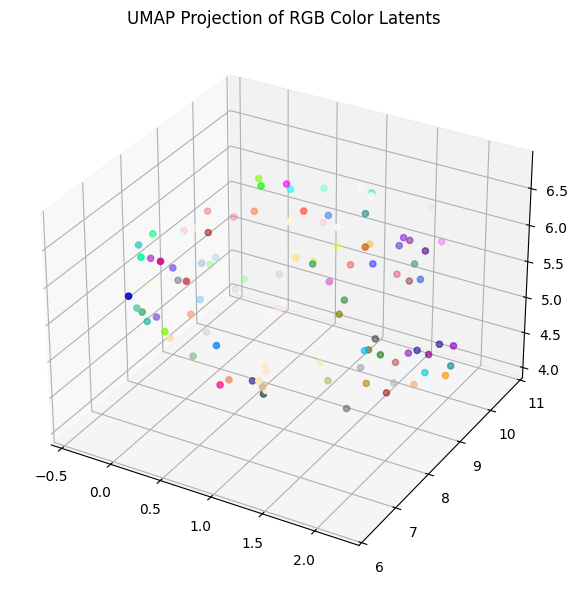

In [27]:
import numpy as np
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Assuming rgb_color_latents = {(255, 0, 0): [...], (0, 255, 0): [...], ...}
rgb_keys = list(rgb_color_latents.keys())
vectors = np.array(list(rgb_color_latents.values()))

# Normalize RGB values from 0–255 to 0–1 for matplotlib
color_values = [tuple(np.array(rgb, dtype=np.float32) / 255.0) for rgb in rgb_keys]

# UMAP to 3D
reducer = umap.UMAP(n_components=3, random_state=42)
embedding = reducer.fit_transform(vectors)

# Plot using pyplot (no labels)
plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.scatter3D(embedding[:, 0], embedding[:, 1], embedding[:, 2], c=color_values)

plt.title('UMAP Projection of RGB Color Latents')
plt.tight_layout()
# Optional: plt.savefig("umap_rgb_latents.png", dpi=300)
plt.show()
